# Stellar Class Discovery EDA

This notebook explores the Kaggle stellar-classification dataset with one purpose:
find new signal that can move balanced accuracy beyond the current public-best
spatial candidates.

The flow starts broad, then narrows to known hard regions: class imbalance,
redshift overlap, low-redshift GALAXY/STAR ambiguity, train/test shift, and
sky-position neighbourhood structure.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CLASS_LABELS, build_features, load_raw  # noqa: E402
from src.features import PHOTOMETRIC_COLUMNS  # noqa: E402
from src.spatial import radec_to_xyz  # noqa: E402

RANDOM_STATE = 42
PLOT_SAMPLE_ROWS = 80_000
SPATIAL_SAMPLE_ROWS = 120_000
NN_SAMPLE_ROWS = 30_000

pd.set_option("display.max_columns", 120)
plt.style.use("default")

In [2]:
def sample_frame(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state).copy()


def describe_train_test_shift(train_s: pd.Series, test_s: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "train_mean": train_s.mean(),
            "test_mean": test_s.mean(),
            "mean_delta": test_s.mean() - train_s.mean(),
            "train_std": train_s.std(),
            "test_std": test_s.std(),
            "train_p01": train_s.quantile(0.01),
            "test_p01": test_s.quantile(0.01),
            "train_p50": train_s.quantile(0.50),
            "test_p50": test_s.quantile(0.50),
            "train_p99": train_s.quantile(0.99),
            "test_p99": test_s.quantile(0.99),
        }
    )


def plot_hist_by_class(
    df: pd.DataFrame,
    column: str,
    bins: int = 80,
    clip_quantiles: tuple[float, float] | None = (0.005, 0.995),
) -> None:
    fig, ax = plt.subplots(figsize=(9, 4))
    values = df[column]
    plot_df = df
    if clip_quantiles is not None:
        lo, hi = values.quantile(list(clip_quantiles))
        plot_df = df[(values >= lo) & (values <= hi)]
    for label in CLASS_LABELS:
        subset = plot_df.loc[plot_df["class"] == label, column]
        ax.hist(subset, bins=bins, alpha=0.45, density=True, label=label)
    ax.set_title(f"{column} distribution by class")
    ax.set_xlabel(column)
    ax.set_ylabel("density")
    ax.legend()
    plt.show()

## 1. Load Data And Validate Schema

The first cell loads the three Kaggle CSVs and checks the submission contract:
train has labels, test does not, and sample-submission ids align exactly with test ids.

In [3]:
train, test, sample_submission = load_raw()
X_train, y_train, categorical_columns, encoder = build_features(train)
X_test, _, _, _ = build_features(test, label_encoder=encoder)

print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"sample_submission: {sample_submission.shape}")
print(f"feature matrix: train={X_train.shape}, test={X_test.shape}")
print(f"categorical columns: {categorical_columns}")

required_train = {"id", "alpha", "delta", "u", "g", "r", "i", "z", "redshift", "class"}
required_test = required_train - {"class"}
assert required_train.issubset(train.columns)
assert required_test.issubset(test.columns)
assert sample_submission["id"].equals(test["id"])
assert set(train["class"]) == set(CLASS_LABELS)
assert not train.isna().any().any()
assert not test.isna().any().any()

train: (577347, 12)
test: (247435, 11)
sample_submission: (247435, 2)
feature matrix: train=(577347, 32), test=(247435, 32)
categorical columns: ['spectral_type', 'galaxy_population', 'spectral_population']


In [4]:
schema = pd.DataFrame(
    {
        "train_dtype": train.dtypes.astype(str),
        "test_dtype": test.dtypes.astype(str),
        "train_missing": train.isna().sum(),
        "test_missing": test.isna().sum(),
        "train_unique": train.nunique(dropna=False),
        "test_unique": test.nunique(dropna=False),
    }
)
schema

,train_dtype,test_dtype,train_missing,test_missing,train_unique,test_unique
alpha,float64,float64,0,0.0,439819,200893.0
class,str,NaN,0,NaN,3,NaN
delta,float64,float64,0,0.0,444062,201819.0
g,float64,float64,0,0.0,577347,247435.0
galaxy_population,str,str,0,0.0,2,2.0
i,float64,float64,0,0.0,577347,247435.0
id,int64,int64,0,0.0,577347,247435.0
r,float64,float64,0,0.0,577347,247435.0
redshift,float64,float64,0,0.0,573975,246031.0
spectral_type,str,str,0,0.0,4,4.0


## 2. Target Balance And Metric Implications

The competition metric is balanced accuracy, so minority-class recall matters as much
as majority-class recall. This section makes the class mix explicit before looking at
feature relationships.

In [5]:
class_counts = train["class"].value_counts().reindex(CLASS_LABELS)
class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "share": class_counts / len(train),
        "balanced_accuracy_weight": 1 / len(CLASS_LABELS),
    }
)
class_summary

,count,share,balanced_accuracy_weight
class,,,
GALAXY,377480,0.653818,0.333333
QSO,117143,0.202899,0.333333
STAR,82724,0.143283,0.333333


notebooks/eda_discovery.ipynb:cell6:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


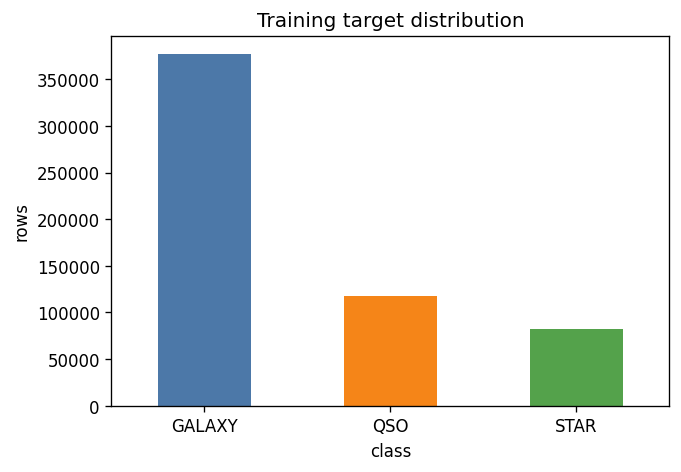

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("Training target distribution")
ax.set_ylabel("rows")
ax.set_xlabel("class")
plt.xticks(rotation=0)
plt.show()

## 3. Numeric Feature Distributions By Class

These plots show which raw numeric features have separable class structure and where
the distributions overlap. Overlap regions are candidate targets for more local or
interaction-heavy features.

In [7]:
numeric_columns = ["alpha", "delta", *PHOTOMETRIC_COLUMNS, "redshift"]
train_plot = sample_frame(train, PLOT_SAMPLE_ROWS)

summary_by_class = train.groupby("class")[numeric_columns].agg(["mean", "std", "median"])
summary_by_class

alpha                              delta                        \
              mean         std      median       mean        std     median   
class                                                                         
GALAXY  178.557241   91.830843  191.988145  21.033443  18.480962  20.014815   
QSO     189.665998  103.471298  186.151513  25.811829  19.583016  29.278918   
STAR    184.178832  104.231295  188.068693  19.858725  19.264123  19.566963   

                u                               g                       \
             mean       std     median       mean       std     median   
class                                                                    
GALAXY  22.989160  1.996769  23.138831  21.270147  1.875915  21.917197   
QSO     21.724756  1.150695  21.700760  21.160314  0.825329  21.246296   
STAR    20.960388  2.016688  20.758202  19.591033  1.766677  19.507411   

                r                               i                       \
             mean       std     median       mean       std     median   
class                                                                    
GALAXY  19.860511  1.690032  20.329629  19.068222  1.499662  19.399104   
QSO     20.918809  0.794862  21.013032  20.767309  0.792321  20.868987   
STAR    19.075853  1.708943  19.034326  18.830555  1.673911  18.815990   

                z                       redshift                      
             mean       std     median      mean       std    median  
class                                                                 
GALAXY  18.629897  1.442609  18.928386  0.509026  0.309139  0.481960  
QSO     20.602139  0.786691  20.697672  1.875641  1.069731  1.798886  
STAR    18.707180  1.677109  18.695904  0.068115  0.064476  0.056492

notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
notebooks/eda_discovery.ipynb:cell2:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


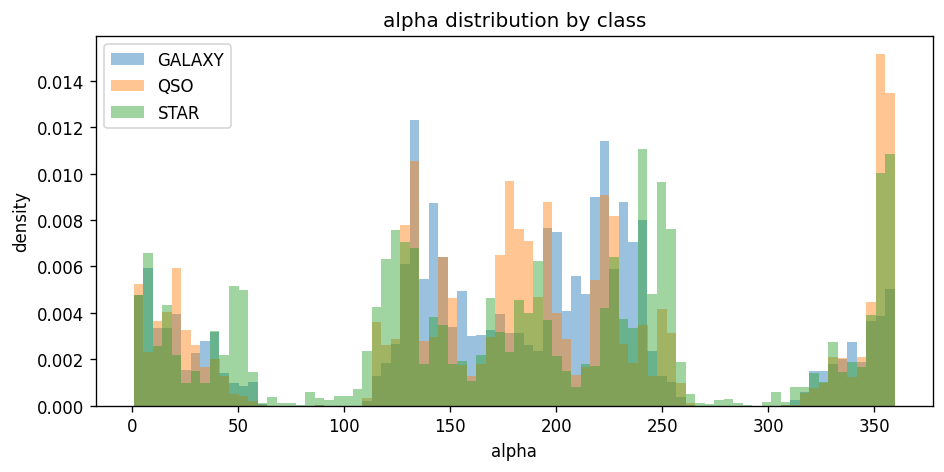

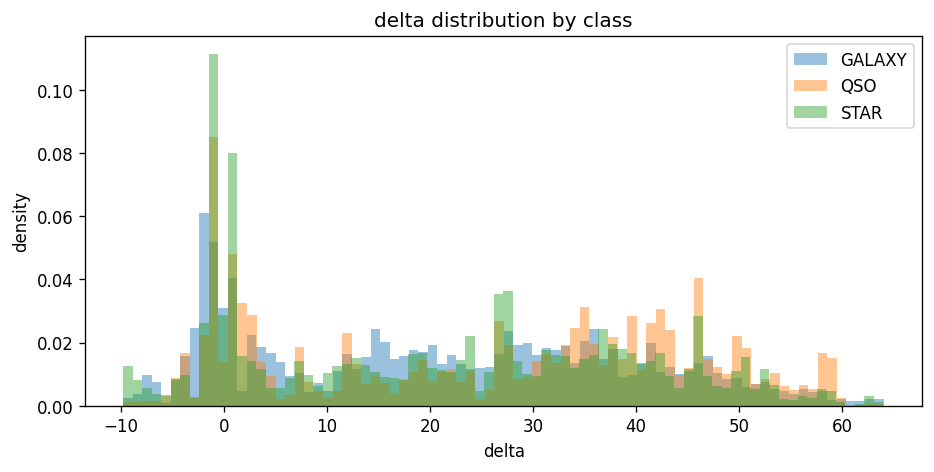

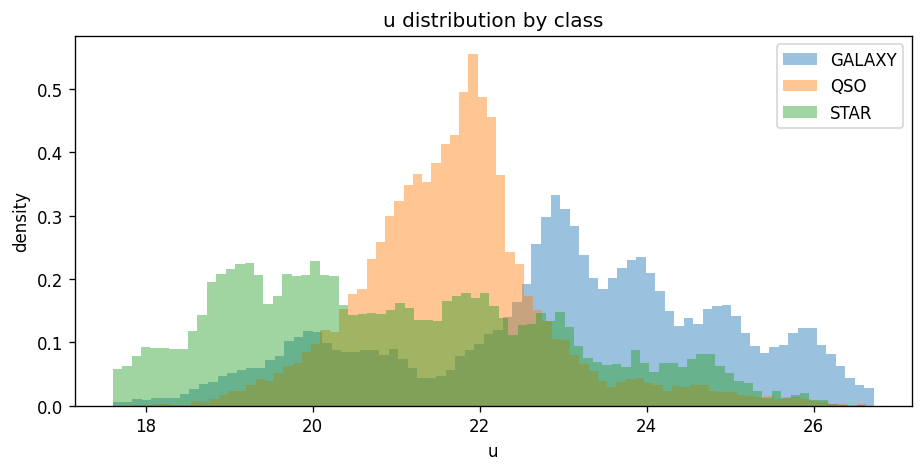

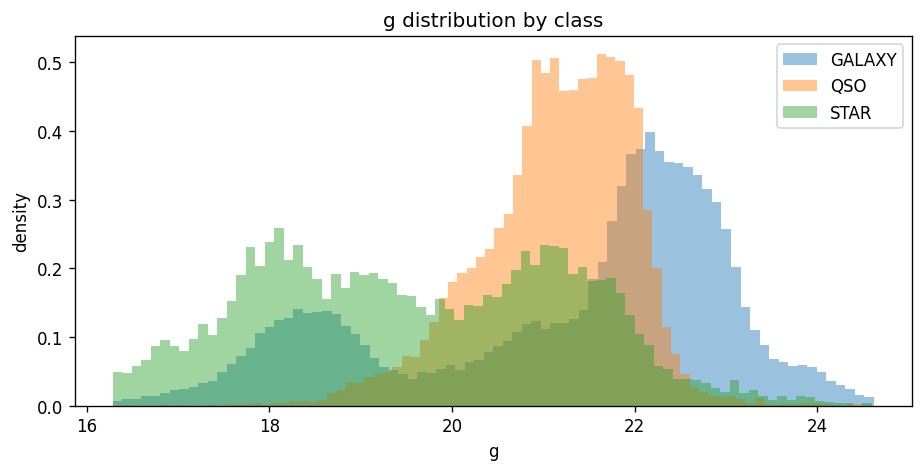

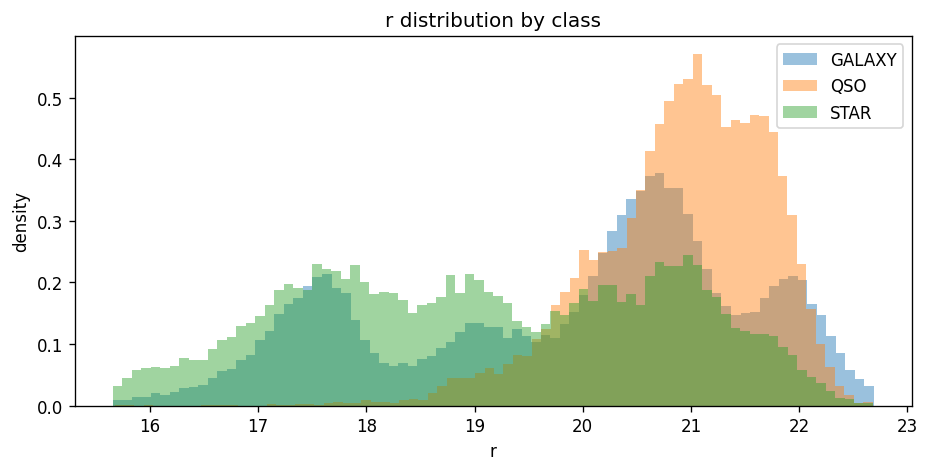

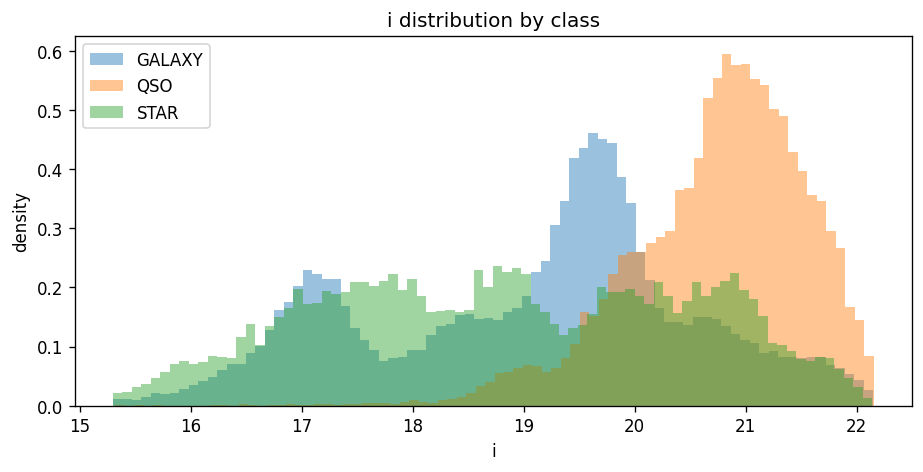

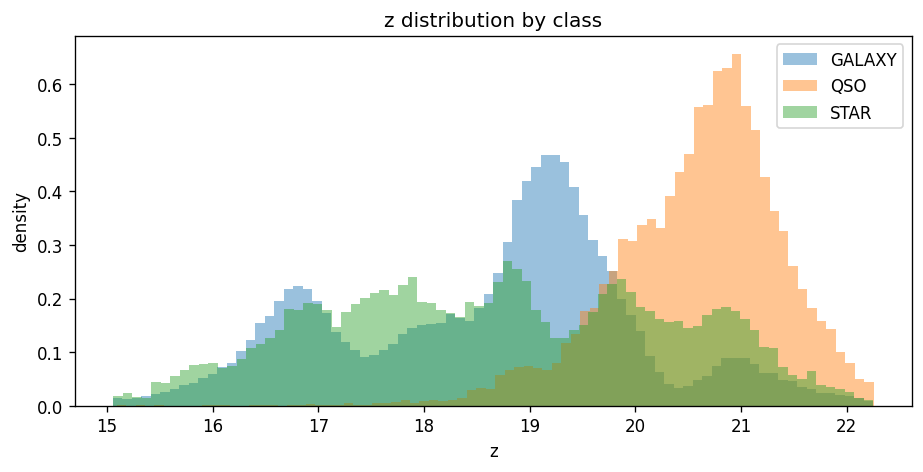

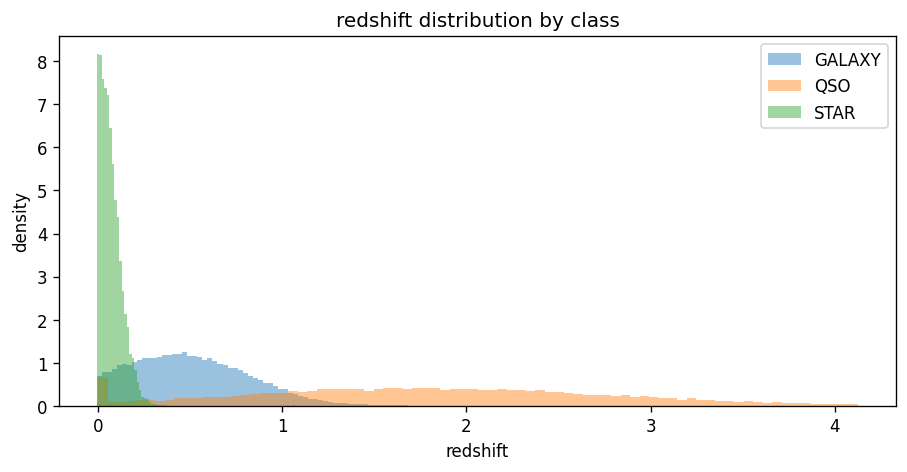

In [8]:
for column in numeric_columns:
    plot_hist_by_class(train_plot, column)

## 4. Redshift Overlap And Low-Redshift Ambiguity

Redshift is the dominant single feature, but the hard cases live where class ranges
overlap. The low-redshift region is especially important because STAR and nearby
GALAXY examples can become hard to separate from tabular features alone.

In [9]:
redshift_bins = pd.IntervalIndex.from_tuples(
    [(-0.01, 0.02), (0.02, 0.08), (0.08, 0.15), (0.15, 0.35), (0.35, 0.75), (0.75, 1.5), (1.5, 8.0)]
)
redshift_table = (
    train.assign(redshift_bin=pd.cut(train["redshift"], bins=redshift_bins))
    .pivot_table(index="redshift_bin", columns="class", values="id", aggfunc="count", fill_value=0)
    .reindex(columns=CLASS_LABELS)
)
redshift_share = redshift_table.div(redshift_table.sum(axis=1), axis=0)
redshift_table.join(redshift_share, rsuffix="_share")

class,GALAXY,QSO,STAR,GALAXY_share,QSO_share,STAR_share
redshift_bin,,,,,,
"(-0.01, 0.02]",7772,3533,19486,0.252411,0.114741,0.632847
"(0.02, 0.08]",17390,571,33587,0.337355,0.011077,0.651567
"(0.08, 0.15]",23752,699,21526,0.516606,0.015203,0.468191
"(0.15, 0.35]",80833,2759,8095,0.881619,0.030092,0.088290
"(0.35, 0.75]",164956,8823,20,0.949119,0.050766,0.000115
"(0.75, 1.5]",81864,28489,7,0.741791,0.258146,0.000063
"(1.5, 8.0]",913,72269,3,0.012475,0.987484,0.000041


notebooks/eda_discovery.ipynb:cell10:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


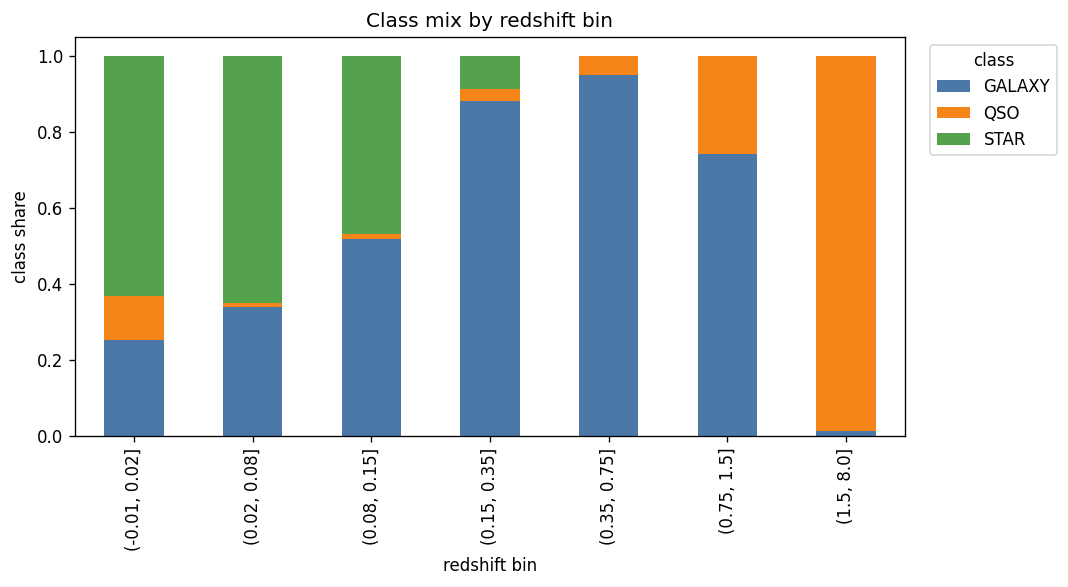

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
redshift_share.plot(kind="bar", stacked=True, ax=ax, color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("Class mix by redshift bin")
ax.set_xlabel("redshift bin")
ax.set_ylabel("class share")
ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
low_z = train[train["redshift"].between(-0.01, 0.15)].copy()
print(f"low-redshift rows: {len(low_z):,} ({len(low_z) / len(train):.1%} of train)")
low_z["class"].value_counts(normalize=True).reindex(CLASS_LABELS).to_frame("share")

low-redshift rows: 128,316 (22.2% of train)


,share
class,
GALAXY,0.381200
QSO,0.037431
STAR,0.581369


## 5. Photometric Color And Magnitude Relationships

Color indices often expose shape that raw magnitudes hide. These cells inspect both
existing engineered color features and two-dimensional views around the low-redshift
ambiguity zone.

In [12]:
color_columns = ["u_g", "g_r", "r_i", "i_z", "u_r", "u_z", "g_z", "r_z"]
color_df = train[["id", "class", "redshift"]].join(X_train[color_columns])
color_df.groupby("class")[color_columns].agg(["mean", "std", "median"])

u_g                           g_r                           r_i  \
            mean       std    median      mean       std    median      mean   
class                                                                          
GALAXY  1.719013  1.162753  1.693772  1.409635  0.577500  1.480926  0.792290   
QSO     0.564442  0.810886  0.383155  0.241505  0.396903  0.213581  0.151500   
STAR    1.369355  0.745693  1.220716  0.515179  0.486873  0.453149  0.245298   

                                 i_z                           u_r            \
             std    median      mean       std    median      mean       std   
class                                                                          
GALAXY  0.415643  0.794782  0.438324  0.352633  0.436826  3.128649  1.355222   
QSO     0.345062  0.141205  0.165170  0.391204  0.168002  0.805947  0.919937   
STAR    0.433526  0.192995  0.123375  0.418212  0.119031  1.884534  0.974620   

                       u_z                           g_z                      \
          median      mean       std    median      mean       std    median   
class                                                                          
GALAXY  3.061393  4.359263  1.491508  4.288000  2.640250  0.897014  2.792916   
QSO     0.585625  1.122616  0.999813  0.906006  0.558175  0.551348  0.510278   
STAR    1.638451  2.253208  1.306372  1.874813  0.883853  0.899105  0.689094   

             r_z                      
            mean       std    median  
class                                 
GALAXY  1.230614  0.533118  1.222277  
QSO     0.316670  0.436150  0.303941  
STAR    0.368674  0.602813  0.283586

notebooks/eda_discovery.ipynb:cell13:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


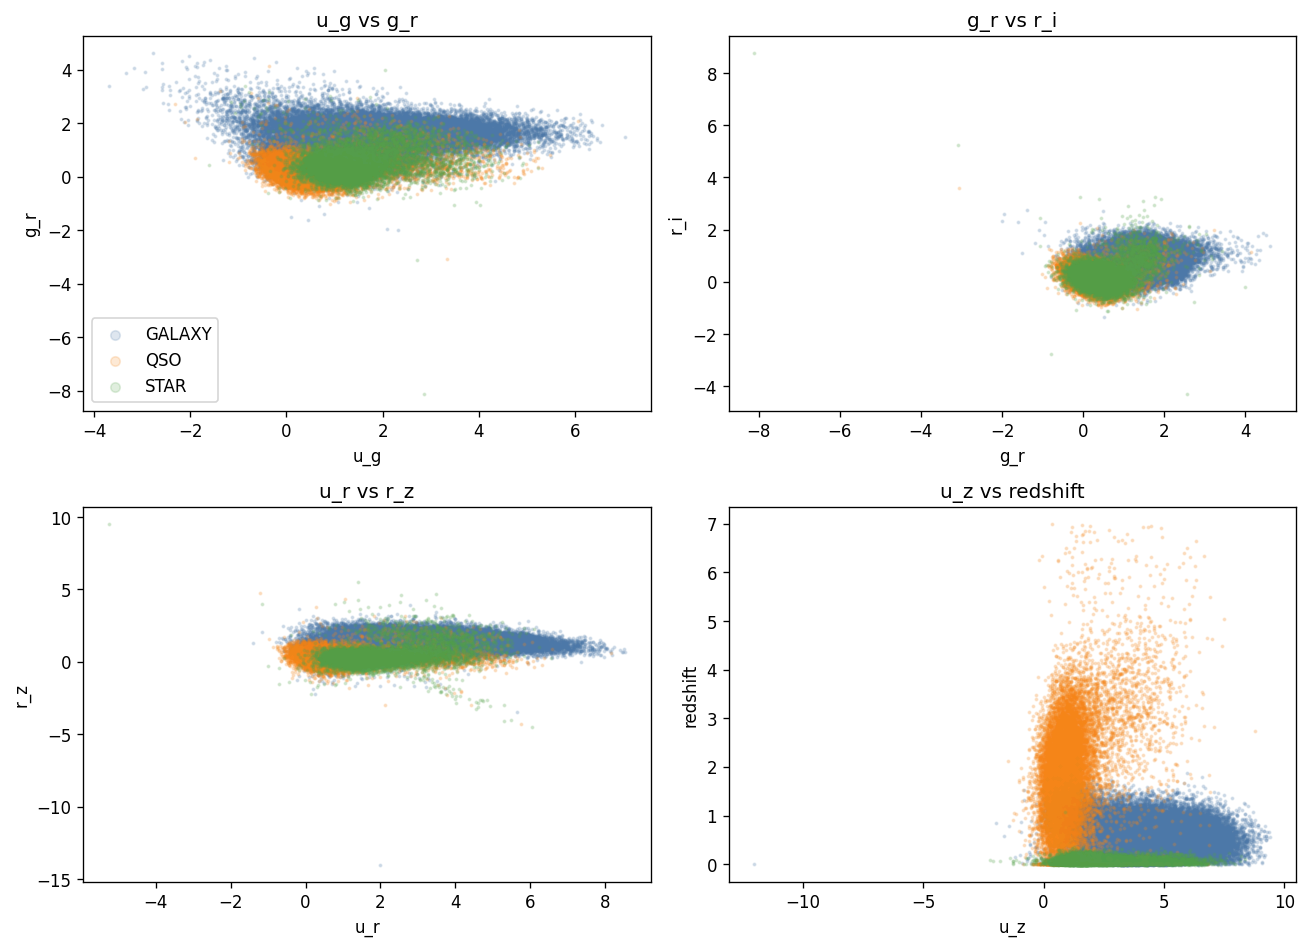

In [13]:
color_plot = sample_frame(color_df, PLOT_SAMPLE_ROWS)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
pairs = [("u_g", "g_r"), ("g_r", "r_i"), ("u_r", "r_z"), ("u_z", "redshift")]
colors = {"GALAXY": "#4c78a8", "QSO": "#f58518", "STAR": "#54a24b"}
for ax, (x_col, y_col) in zip(axes.ravel(), pairs, strict=True):
    for label in CLASS_LABELS:
        subset = color_plot[color_plot["class"] == label]
        ax.scatter(subset[x_col], subset[y_col], s=2, alpha=0.18, label=label, c=colors[label])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
axes[0, 0].legend(markerscale=4)
plt.tight_layout()
plt.show()

notebooks/eda_discovery.ipynb:cell14:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


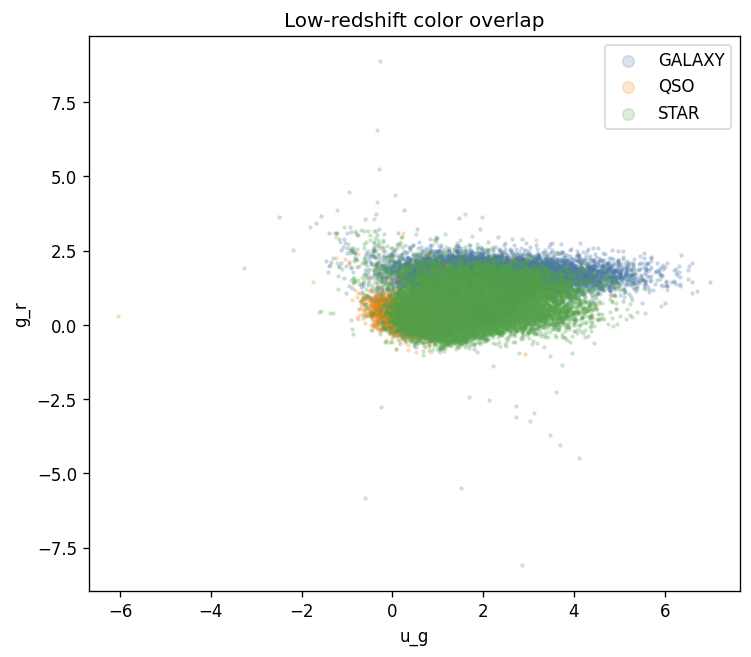

In [14]:
low_z_color = sample_frame(color_df[color_df["redshift"].between(-0.01, 0.15)], PLOT_SAMPLE_ROWS)
fig, ax = plt.subplots(figsize=(7, 6))
for label in CLASS_LABELS:
    subset = low_z_color[low_z_color["class"] == label]
    ax.scatter(subset["u_g"], subset["g_r"], s=3, alpha=0.2, label=label, c=colors[label])
ax.set_title("Low-redshift color overlap")
ax.set_xlabel("u_g")
ax.set_ylabel("g_r")
ax.legend(markerscale=4)
plt.show()

## 6. Categorical Signal

The categorical fields are useful but not label leaks. This section inspects class mix
by category and by the engineered `spectral_population` interaction.

In [15]:
categorical_source = train[["class", "spectral_type", "galaxy_population"]].join(
    X_train[["spectral_population"]]
)
for column in ["spectral_type", "galaxy_population", "spectral_population"]:
    counts = pd.crosstab(categorical_source[column], categorical_source["class"]).reindex(columns=CLASS_LABELS)
    display(counts)
    display(counts.div(counts.sum(axis=1), axis=0))

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,24240,61514,36368
G/K,61627,20921,25998
M,288023,3889,11411
O/B,3590,30819,8947


class,GALAXY,QSO,STAR
spectral_type,,,
A/F,0.198490,0.503709,0.297801
G/K,0.567750,0.192739,0.239511
M,0.949559,0.012821,0.037620
O/B,0.082803,0.710836,0.206361


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,88962,108274,60546
Red_Sequence,288518,8869,22178


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345106,0.420022,0.234873
Red_Sequence,0.902846,0.027753,0.069401


class,GALAXY,QSO,STAR
spectral_population,,,
A/F__Blue_Cloud,20316,58454,32772
A/F__Red_Sequence,3924,3060,3596
G/K__Blue_Cloud,28115,18154,17649
G/K__Red_Sequence,33512,2767,8349
M__Blue_Cloud,37062,1447,1597
M__Red_Sequence,250961,2442,9814
O/B__Blue_Cloud,3469,30219,8528
O/B__Red_Sequence,121,600,419


class,GALAXY,QSO,STAR
spectral_population,,,
A/F__Blue_Cloud,0.182138,0.524054,0.293809
A/F__Red_Sequence,0.370888,0.289225,0.339887
G/K__Blue_Cloud,0.439860,0.284020,0.276119
G/K__Red_Sequence,0.750919,0.062001,0.187080
M__Blue_Cloud,0.924101,0.036079,0.039819
M__Red_Sequence,0.953438,0.009278,0.037285
O/B__Blue_Cloud,0.082173,0.715819,0.202009
O/B__Red_Sequence,0.106140,0.526316,0.367544


## 7. Train/Test Shift Checks

Public score gaps often come from distribution mismatch. These checks compare train
and test numerics, categorical levels, and sky coverage before proposing new features.

In [16]:
shift_table = pd.DataFrame(
    {
        column: describe_train_test_shift(train[column], test[column])
        for column in numeric_columns
    }
).T
shift_table["abs_mean_delta_over_train_std"] = (
    shift_table["mean_delta"].abs() / shift_table["train_std"].replace(0, np.nan)
)
shift_table.sort_values("abs_mean_delta_over_train_std", ascending=False)

,train_mean,test_mean,mean_delta,train_std,test_std,train_p01,test_p01,train_p50,test_p50,train_p99,test_p99,abs_mean_delta_over_train_std
alpha,181.616673,181.360629,-0.256043,96.242941,96.213374,1.751293,1.810075,188.681465,188.559428,358.966505,358.936755,0.002660
redshift,0.723135,0.724780,0.001645,0.810070,0.810582,-0.003506,-0.003464,0.497525,0.498598,3.682179,3.693098,0.002031
i,19.378911,19.381860,0.002949,1.580059,1.581880,15.693255,15.676235,19.631642,19.632235,22.036599,22.033525,0.001866
r,19.962811,19.965651,0.002840,1.648964,1.650949,16.008655,15.987094,20.431153,20.431512,22.494130,22.506194,0.001722
g,21.007273,21.009837,0.002564,1.795426,1.798633,16.641877,16.613937,21.467820,21.469175,24.222697,24.233890,0.001428
z,19.041136,19.043151,0.002015,1.584365,1.587103,15.453469,15.434572,19.188598,19.196316,22.021812,22.021609,0.001272
delta,21.834654,21.853898,0.019244,18.933570,18.931367,-8.076780,-8.079733,21.484412,21.452023,60.558596,60.563349,0.001016
u,22.441926,22.442070,0.000144,2.018135,2.019044,17.950424,17.932704,22.570222,22.569616,26.477518,26.481525,0.000071


In [17]:
for column in ["spectral_type", "galaxy_population"]:
    train_share = train[column].value_counts(normalize=True).rename("train_share")
    test_share = test[column].value_counts(normalize=True).rename("test_share")
    display(pd.concat([train_share, test_share], axis=1).fillna(0).assign(delta=lambda x: x["test_share"] - x["train_share"]))

,train_share,test_share,delta
spectral_type,,,
M,0.525374,0.524792,-0.000581
A/F,0.211523,0.211858,0.000335
G/K,0.188008,0.189137,0.001128
O/B,0.075095,0.074213,-0.000882


,train_share,test_share,delta
galaxy_population,,,
Red_Sequence,0.553506,0.552016,-0.00149
Blue_Cloud,0.446494,0.447984,0.00149


notebooks/eda_discovery.ipynb:cell18:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


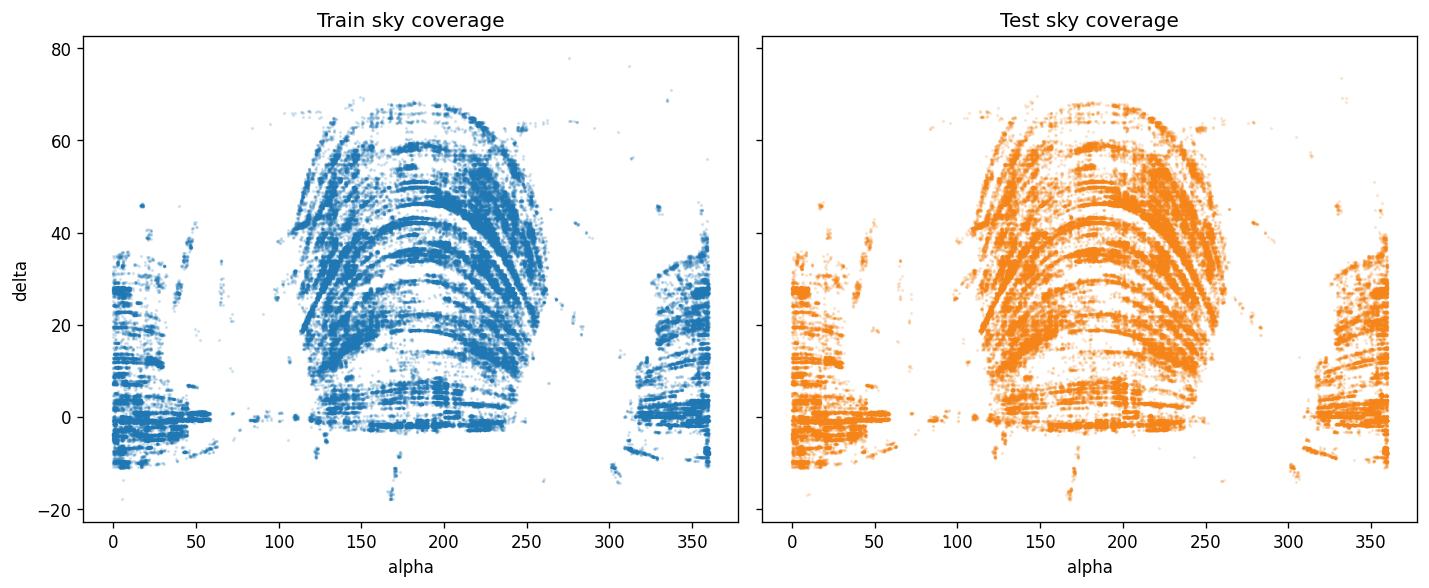

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sample_frame(train, SPATIAL_SAMPLE_ROWS).plot.scatter(
    x="alpha", y="delta", s=1, alpha=0.15, ax=axes[0], title="Train sky coverage"
)
sample_frame(test, SPATIAL_SAMPLE_ROWS).plot.scatter(
    x="alpha", y="delta", s=1, alpha=0.15, ax=axes[1], title="Test sky coverage", color="#f58518"
)
plt.tight_layout()
plt.show()

## 8. Spatial Structure Discovery

The strongest known lift came from spatial-neighbour features. These cells make the
structure visible and provide a cheap nearest-neighbour class-agreement diagnostic.

notebooks/eda_discovery.ipynb:cell19:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


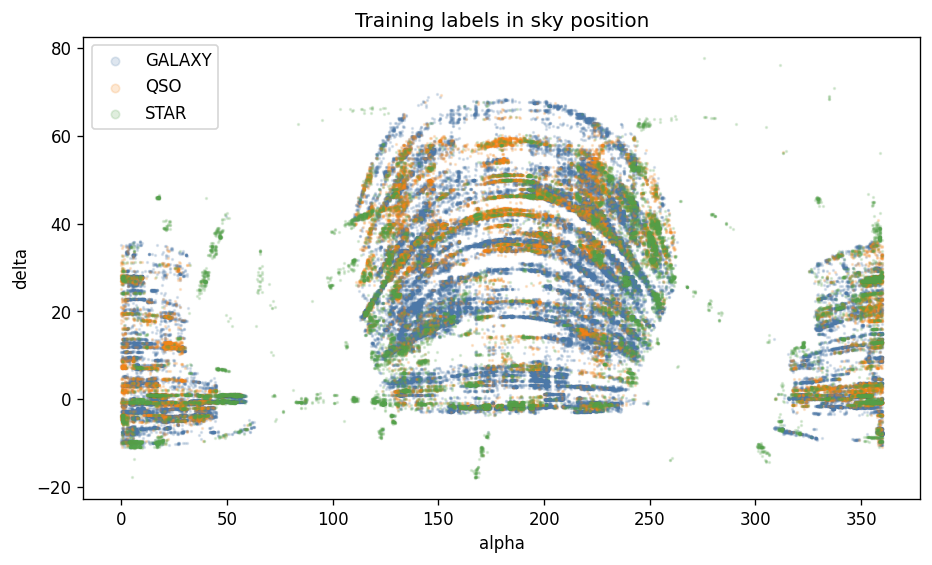

In [19]:
spatial_plot = sample_frame(train, SPATIAL_SAMPLE_ROWS)
fig, ax = plt.subplots(figsize=(9, 5))
for label in CLASS_LABELS:
    subset = spatial_plot[spatial_plot["class"] == label]
    ax.scatter(subset["alpha"], subset["delta"], s=1, alpha=0.18, label=label, c=colors[label])
ax.set_title("Training labels in sky position")
ax.set_xlabel("alpha")
ax.set_ylabel("delta")
ax.legend(markerscale=5)
plt.show()

In [20]:
nn_sample = sample_frame(train, NN_SAMPLE_ROWS)
xyz = radec_to_xyz(nn_sample["alpha"].to_numpy(), nn_sample["delta"].to_numpy())
labels = encoder.transform(nn_sample["class"])
nn = NearestNeighbors(n_neighbors=11, n_jobs=-1).fit(xyz)
distances, indices = nn.kneighbors(xyz)
neighbour_labels = labels[indices[:, 1:]]

rows = []
for k in [1, 3, 5, 10]:
    same_class = (neighbour_labels[:, :k] == labels[:, None]).mean()
    majority_vote = np.apply_along_axis(
        lambda row: np.bincount(row, minlength=len(CLASS_LABELS)).argmax(),
        1,
        neighbour_labels[:, :k],
    )
    rows.append(
        {
            "k": k,
            "same_class_pair_rate": same_class,
            "majority_vote_balanced_accuracy": balanced_accuracy_score(labels, majority_vote),
            "median_distance": np.median(distances[:, k]),
        }
    )

pd.DataFrame(rows)

,k,same_class_pair_rate,majority_vote_balanced_accuracy,median_distance
0,1,0.697833,0.580548,0.002126
1,3,0.690256,0.588088,0.004819
2,5,0.683340,0.591578,0.006963
3,10,0.667697,0.585826,0.011298


In [21]:
fold_ids = np.zeros(len(nn_sample), dtype=int)
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for fold, (_, valid_idx) in enumerate(splitter.split(nn_sample, labels)):
    fold_ids[valid_idx] = fold
pd.Series(fold_ids).value_counts().sort_index().to_frame("rows_per_fold")

,rows_per_fold
0,6000
1,6000
2,6000
3,6000
4,6000


## 9. Residual Analysis Hooks

This section reads existing experiment artifacts when they are present. It keeps the
notebook useful as an EDA artifact without requiring every generated probability cache.

In [22]:
experiment_paths = [
    Path("experiments/16_spatial_xgb.json"),
    Path("experiments/19_loo_spatial_final.json"),
    Path("experiments/23_loo_spatial_star_tilt.json"),
    Path("experiments/26_loo_spatial_xgb_calibrated.json"),
]
experiment_records = []
for path in experiment_paths:
    if not path.exists():
        continue
    with path.open() as handle:
        payload = json.load(handle)
    experiment_records.append(
        {
            "path": str(path),
            "oof_balanced_accuracy": payload.get("oof_balanced_accuracy")
            or payload.get("tuned_oof_balanced_accuracy"),
            "public_score": payload.get("public_score"),
            "submission_path": payload.get("submission_path"),
        }
    )
pd.DataFrame(experiment_records)

,path,oof_balanced_accuracy,public_score,submission_path
0,experiments/16_spatial_xgb.json,None,NaN,/Users/linrichuang/Github/predicting_stellar_c...
1,experiments/19_loo_spatial_final.json,None,0.96970,/Users/linrichuang/Github/predicting_stellar_c...
2,experiments/23_loo_spatial_star_tilt.json,None,0.96970,submissions/23_loo_spatial_star_tilt.csv
3,experiments/26_loo_spatial_xgb_calibrated.json,None,0.96956,submissions/26_loo_spatial_xgb_calibrated.csv


In [23]:
submission_paths = [
    Path("submissions/16_spatial_blend.csv"),
    Path("submissions/19_loo_spatial_final.csv"),
    Path("submissions/23_loo_spatial_star_tilt.csv"),
    Path("submissions/26_loo_spatial_xgb_calibrated.csv"),
]
submission_counts = []
for path in submission_paths:
    if path.exists():
        counts = pd.read_csv(path)["class"].value_counts().reindex(CLASS_LABELS, fill_value=0)
        submission_counts.append(counts.rename(path.name))
if submission_counts:
    submission_count_table = pd.concat(submission_counts, axis=1).T
    display(submission_count_table)

class,GALAXY,QSO,STAR
16_spatial_blend.csv,156730,51344,39361
19_loo_spatial_final.csv,156538,51401,39496
23_loo_spatial_star_tilt.csv,156585,51344,39506
26_loo_spatial_xgb_calibrated.csv,156551,51403,39481


In [24]:
if Path("experiments/16_spatial_xgb.json").exists():
    with Path("experiments/16_spatial_xgb.json").open() as handle:
        spatial_payload = json.load(handle)
    keys_of_interest = [
        "tuned_oof_balanced_accuracy",
        "oof_balanced_accuracy",
        "multipliers",
        "blend_weights",
        "per_class_recall",
    ]
    {key: spatial_payload.get(key) for key in keys_of_interest if key in spatial_payload}

## 10. Discovery Hypotheses And Next Experiments

This final section translates the EDA into experiment ideas. Keep this list updated
after inspecting notebook outputs, especially the spatial and low-redshift cells.

1. Build local photometric-neighbour features: nearest neighbours in sky position
   plus color/magnitude similarity, not raw redshift distance.
2. Try logit-space blending for spatial model probabilities before multiplier tuning.
3. Inspect low-redshift GALAXY/STAR regions for class-conditional color pockets.
4. Compare final-only LOO spatial variants against honest OOF spatial features to
   isolate train/test spatial-density mismatch.
5. Add a small residual report for rows where spatial models disagree with the
   strongest non-spatial model family.